In [1]:
import pandas as pd
file = "C:\\Users\\eyasf\\OneDrive\\Desktop\\projet_raies\\raw_data\\FX Data.xlsx"

xls = pd.ExcelFile(file)
print(xls.sheet_names)


['InterBancaire', 'BCT Fixing EUR', 'BCT Fixing USD', 'EUR-GBP-JPY vs USD']


In [ ]:
#importing the data
Bct_fixing_USD = pd.read_excel(xls, "BCT Fixing USD")
Interbancaire = pd.read_excel(xls, "InterBancaire")
print(Bct_fixing_USD.head())
print(Interbancaire.head())

  Exchange Date     Bid     Ask  Mid Price
0    2020-04-10  2.9049  2.9079    2.90640
1    2020-04-13  2.8954  2.8982    2.89680
2    2020-04-14  2.8877  2.8905    2.88910
3    2020-04-15  2.8938  2.8966    2.89520
4    2020-04-16  2.8999  2.9028    2.90135
         Date     DZD     SAR     CAD      DKK     USD    GBP      JPY  \
0  2004-01-01  0.1781  3.3988  0.9138  20.5241  1.2741  2.257  11.2003   
1  2004-01-02  0.1781  3.3988  0.9138  20.5241  1.2741  2.257  11.2003   
2  2004-01-03  0.1781  3.3988  0.9138  20.5241  1.2741  2.257  11.2003   
3  2004-01-04  0.1781  3.3988  0.9138  20.5241  1.2741  2.257  11.2003   
4  2004-01-05  0.1781  3.3988  0.9138  20.5241  1.2741  2.257  11.2003   

      MAD      NOK  ...     CHF     KWD     AED     EUR  Unnamed: 15  \
0  1.3957  18.4491  ...  9.9535  4.3237  3.4717  1.5271          NaN   
1  1.3957  18.4491  ...  9.9535  4.3237  3.4717  1.5271          NaN   
2  1.3957  18.4491  ...  9.9535  4.3237  3.4717  1.5271          NaN   
3  1.3957

In [6]:
# cleaning the interbank 
IB = Interbancaire[["Date", "USD"]]
IB = IB.rename(columns={"USD": "USD_IB"})
IB['Date'] = pd.to_datetime(IB['Date'])
IB.head()


,Date,USD_IB
0,2004-01-01,1.2741
1,2004-01-02,1.2741
2,2004-01-03,1.2741
3,2004-01-04,1.2741
4,2004-01-05,1.2741


In [9]:
# clean fixing 
Fix = Bct_fixing_USD[['Exchange Date','Mid Price']]
Fix.columns = ['Date','Fixing_USD']
Fix['Date'] = pd.to_datetime(Fix['Date'])
Fix.head()


C:\Users\eyasf\AppData\Local\Temp\ipykernel_21400\913866407.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Fix['Date'] = pd.to_datetime(Fix['Date'])


,Date,Fixing_USD
0,2020-04-10,2.90640
1,2020-04-13,2.89680
2,2020-04-14,2.88910
3,2020-04-15,2.89520
4,2020-04-16,2.90135


In [11]:
IB = IB[IB['Date'] >= Fix['Date'].min()]
IB.head()

,Date,USD_IB
5944,2020-04-10,2.9107
5945,2020-04-11,2.9107
5946,2020-04-12,2.9107
5947,2020-04-13,2.8924
5948,2020-04-14,2.8894


In [13]:
#merge the two datasets
df = pd.merge(IB, Fix, on='Date', how='inner')
df.head()

,Date,USD_IB,Fixing_USD
0,2020-04-10,2.9107,2.90640
1,2020-04-13,2.8924,2.89680
2,2020-04-14,2.8894,2.88910
3,2020-04-15,2.8874,2.89520
4,2020-04-16,2.9006,2.90135


In [15]:
df['Fixing_lag'] = df['Fixing_USD'].shift(1)
df.head()

,Date,USD_IB,Fixing_USD,Fixing_lag
0,2020-04-10,2.9107,2.90640,NaN
1,2020-04-13,2.8924,2.89680,2.9064
2,2020-04-14,2.8894,2.88910,2.8968
3,2020-04-15,2.8874,2.89520,2.8891
4,2020-04-16,2.9006,2.90135,2.8952


In [18]:
#spread
df['Spread_same'] = df['USD_IB'] - df['Fixing_USD']
df['Spread_lag'] = df['USD_IB'] - df['Fixing_lag']
df.head()

,Date,USD_IB,Fixing_USD,Fixing_lag,Spread_same,Spread_lag
0,2020-04-10,2.9107,2.90640,NaN,0.00430,NaN
1,2020-04-13,2.8924,2.89680,2.9064,-0.00440,-0.0140
2,2020-04-14,2.8894,2.88910,2.8968,0.00030,-0.0074
3,2020-04-15,2.8874,2.89520,2.8891,-0.00780,-0.0017
4,2020-04-16,2.9006,2.90135,2.8952,-0.00075,0.0054


In [19]:
df = df.dropna()

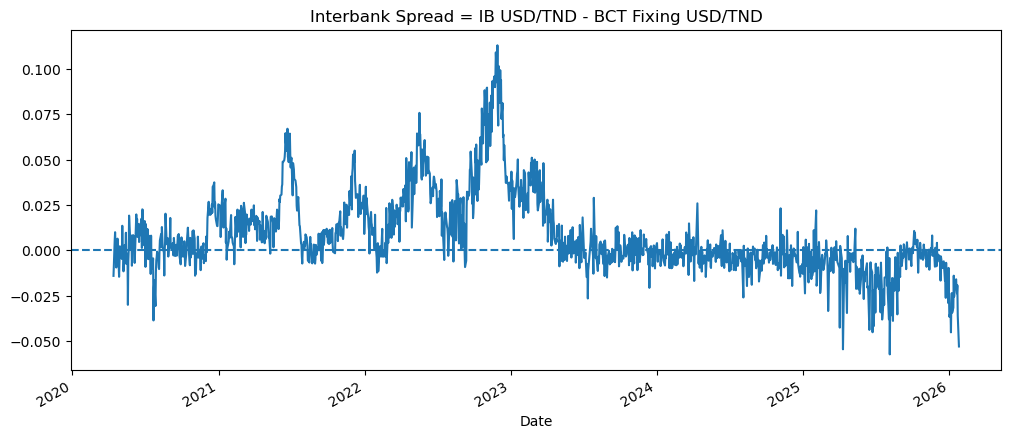

In [21]:
# Visualization 
import matplotlib.pyplot as plt
df.set_index('Date')['Spread_lag'].plot(figsize=(12,5))
plt.title("Interbank Spread = IB USD/TND - BCT Fixing USD/TND")
plt.axhline(0, linestyle='--')
plt.show()


In [ ]:
#interpretation doc

In [23]:
# description 
spread_stats = df['Spread_lag'].describe()
skewness = df['Spread_lag'].skew()
kurtosis = df['Spread_lag'].kurt()

print(spread_stats)
print("Skewness:", skewness)
print("Kurtosis:", kurtosis)

count    1460.000000
mean        0.008454
std         0.022065
min        -0.057250
25%        -0.004500
50%         0.002400
75%         0.018425
max         0.113000
Name: Spread_lag, dtype: float64
Skewness: 1.239707814402021
Kurtosis: 2.657810984240706


In [24]:
#ADF 
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(df['Spread_lag'])
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])
print("Critical Values:", adf_result[4])

ADF Statistic: -2.7258928783240903
p-value: 0.06966384000979066
Critical Values: {'1%': -3.4348772553489617, '5%': -2.8635394783531085, '10%': -2.5678345067434516}


In [25]:
#interpretation : Si le spread est élevé aujourd’hui, que va-t-il se passer demain ?”
import statsmodels.api as sm

df['Spread_lag1'] = df['Spread_lag'].shift(1)
df_ar = df.dropna()

X = sm.add_constant(df_ar['Spread_lag1'])
y = df_ar['Spread_lag']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Spread_lag   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.760
Method:                 Least Squares   F-statistic:                     4605.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:39:07   Log-Likelihood:                 4534.6
No. Observations:                1459   AIC:                            -9065.
Df Residuals:                    1457   BIC:                            -9055.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0010      0.000      3.449      

In [ ]:
# AR(2)
df['Spread_lag2'] = df['Spread_lag'].shift(2)
df_ar2=df.dropna()
X= sm.add_constant(df_ar2[['Spread_lag1','Spread_lag2']])
y = df_ar2['Spread_lag']
model2 = sm.OLS(y,X).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:             Spread_lag   R-squared:                       0.808
Model:                            OLS   Adj. R-squared:                  0.808
Method:                 Least Squares   F-statistic:                     3063.
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:21:21   Log-Likelihood:                 4695.2
No. Observations:                1458   AIC:                            -9384.
Df Residuals:                    1455   BIC:                            -9369.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0005      0.000      1.979      

In [27]:
#AR(3)
df['Spread_lag3'] = df['Spread_lag'].shift(3)
df_ar3=df.dropna()
X= sm.add_constant(df_ar3[['Spread_lag1','Spread_lag2','Spread_lag3']])
y = df_ar3['Spread_lag']
model3 = sm.OLS(y,X).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:             Spread_lag   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     2196.
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:29:09   Log-Likelihood:                 4735.6
No. Observations:                1457   AIC:                            -9463.
Df Residuals:                    1453   BIC:                            -9442.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0004      0.000      1.439      

In [28]:
df['Spread_lag4'] = df['Spread_lag'].shift(4)
df_ar4=df.dropna()
X= sm.add_constant(df_ar4[['Spread_lag1','Spread_lag2','Spread_lag3','Spread_lag4']])
y = df_ar4['Spread_lag']
model4 = sm.OLS(y,X).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:             Spread_lag   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                     1703.
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:30:00   Log-Likelihood:                 4752.7
No. Observations:                1456   AIC:                            -9495.
Df Residuals:                    1451   BIC:                            -9469.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0003      0.000      1.111      